<a href="https://colab.research.google.com/github/Aaryant74/Data_Science_Assignments/blob/main/15_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Preprocessing:**

1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.

2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.

3.	Use multiple visualizations to understand the hidden patterns in the dataset


In [ ]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_excel("/content/EastWestAirlines.xlsx", sheet_name="data")

# View data
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [ ]:
# Check missing values
df.isnull().sum()

# Fill missing values (mean for numerical columns)
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
# Remove Outliers (Using IQR)
def remove_outliers(df):
    for col in df.select_dtypes(include=np.number).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

df = remove_outliers(df)

In [ ]:
# Feature Scaling
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

# Convert back to DataFrame
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)

df_scaled.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-1.956995,-0.077938,0.0,-0.38415,0.0,0.0,-0.689235,-0.770036,0.0,0.0,1.631957,0.0
1,-1.956140,-0.402719,0.0,-0.38415,0.0,0.0,-0.678658,-0.612157,0.0,0.0,1.616613,0.0
2,-1.955284,0.404215,0.0,-0.38415,0.0,0.0,0.329458,-0.296398,0.0,0.0,1.648259,0.0
3,-1.954428,-0.565784,0.0,-0.38415,0.0,0.0,-0.605139,-0.770036,0.0,0.0,1.608942,0.0
4,-1.952717,-0.505784,0.0,-0.38415,0.0,0.0,-0.734120,-0.927916,0.0,0.0,1.604147,0.0


In [ ]:
# EDA
# Basic Info
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1427 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                1427 non-null   int64
 1   Balance            1427 non-null   int64
 2   Qual_miles         1427 non-null   int64
 3   cc1_miles          1427 non-null   int64
 4   cc2_miles          1427 non-null   int64
 5   cc3_miles          1427 non-null   int64
 6   Bonus_miles        1427 non-null   int64
 7   Bonus_trans        1427 non-null   int64
 8   Flight_miles_12mo  1427 non-null   int64
 9   Flight_trans_12    1427 non-null   int64
 10  Days_since_enroll  1427 non-null   int64
 11  Award?             1427 non-null   int64
dtypes: int64(12)
memory usage: 144.9 KB


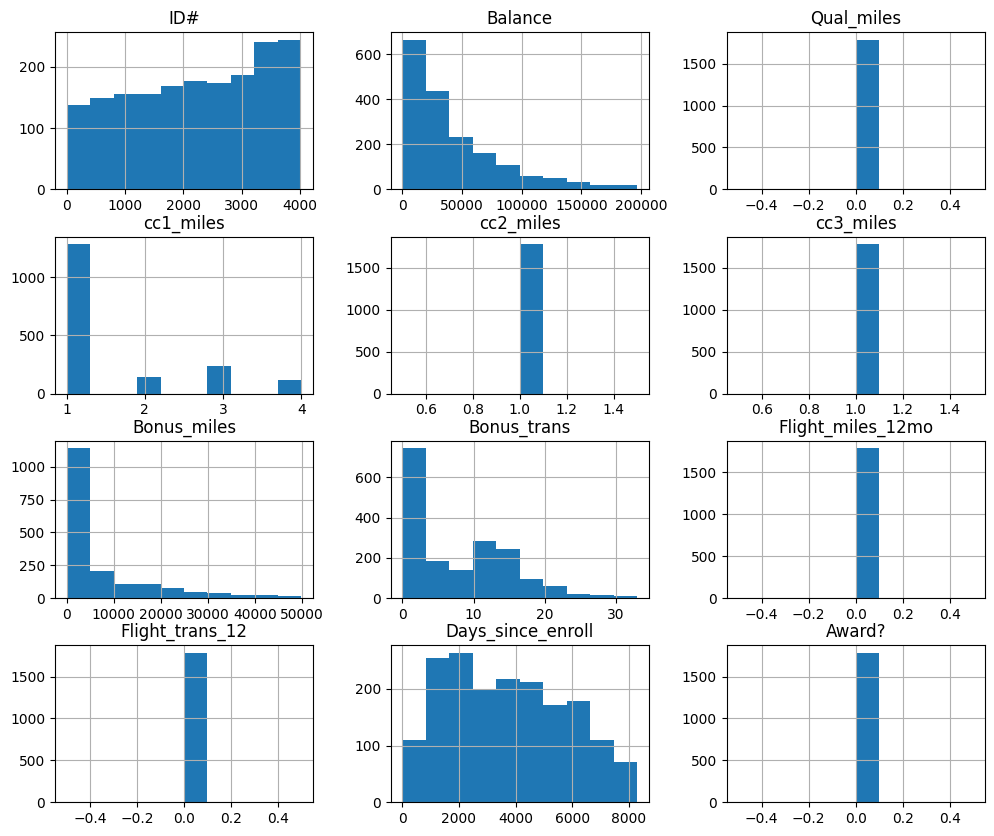

In [ ]:
# Distribution Plots (Histogram)
df.hist(figsize=(12,10))
plt.show()

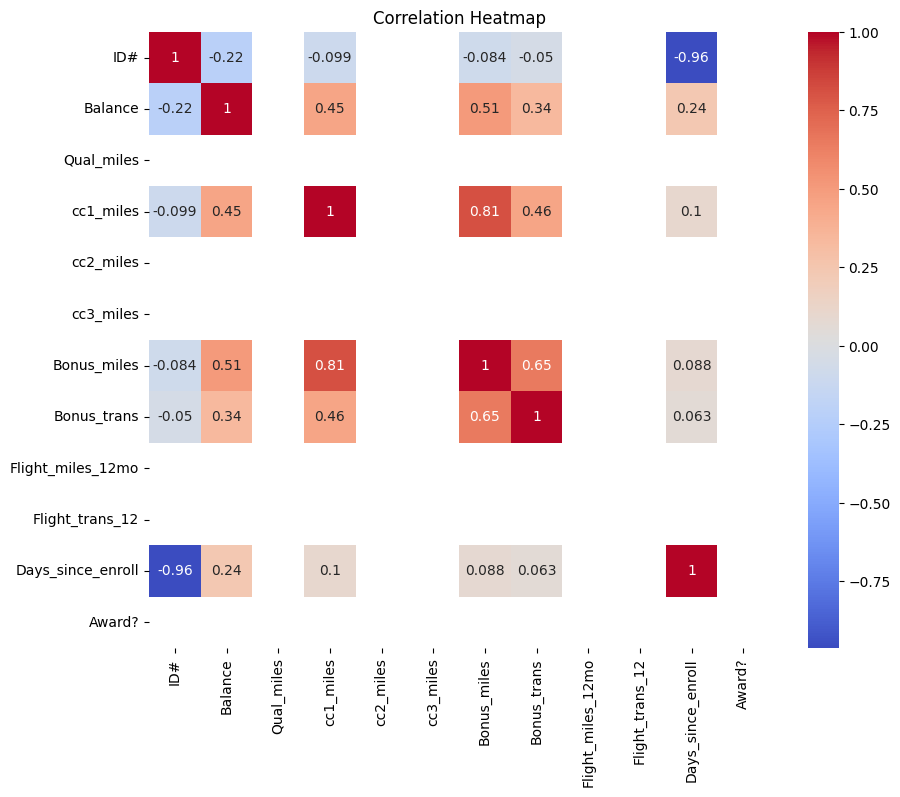

In [ ]:
# Using Correlation Heatmap to find relationship between features
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

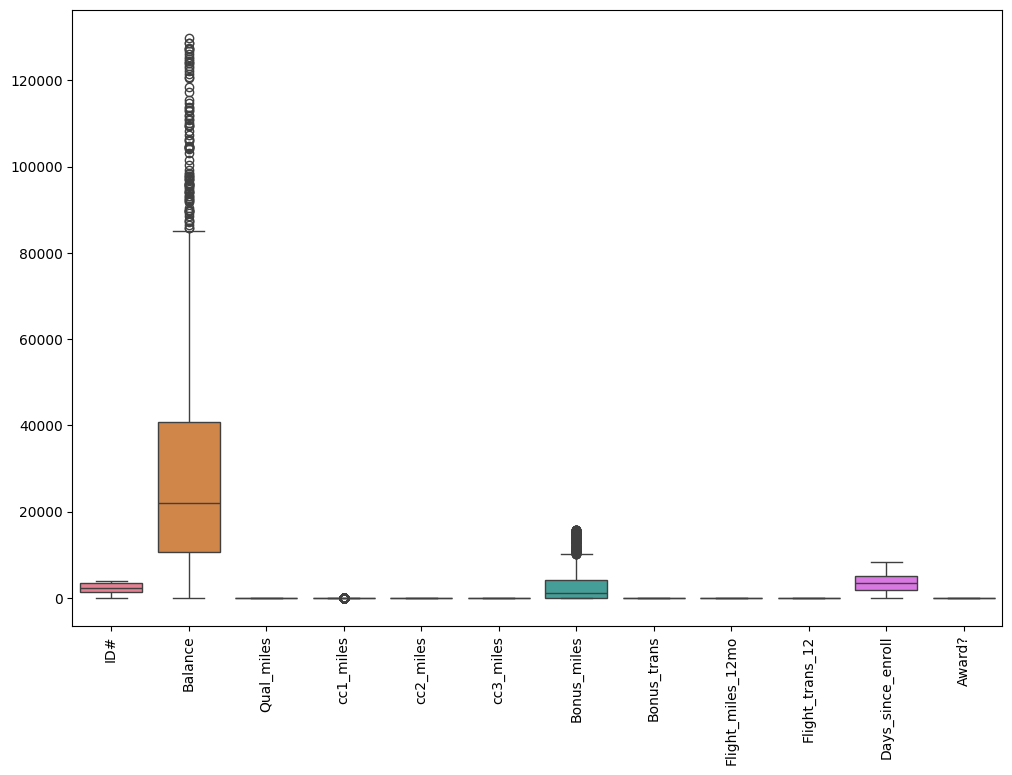

In [ ]:
# Boxplots (Outlier Visualization)
plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

**Implementing Clustering Algorithms:**

1. Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.

2. Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.

3. Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.


In [ ]:
# Importing libraries
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

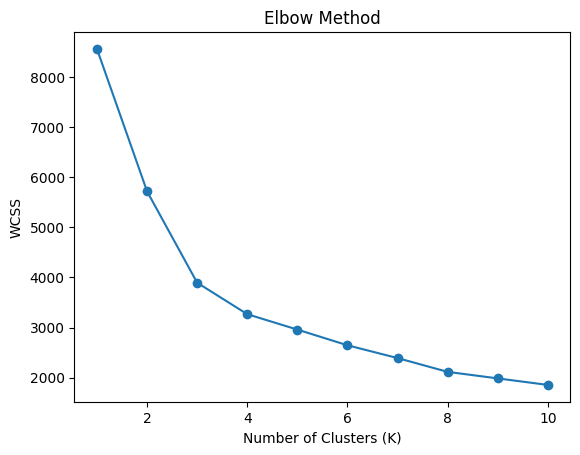

Silhouette Score (K-Means): 0.34849921314505655


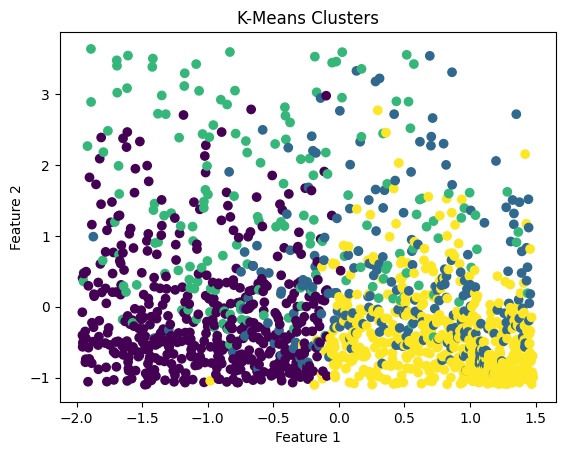

In [ ]:
# K-Means Clustering
# Elbow Method (Find Best K)
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

# Apply K-Means with Optimal K
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(df_scaled)

# Add cluster labels to dataframe
df['KMeans_Cluster'] = kmeans_labels

# Evaluate K-Means
score = silhouette_score(df_scaled, kmeans_labels)
print("Silhouette Score (K-Means):", score)

# Visualize K-Means Clusters (2D)
plt.scatter(df_scaled.iloc[:,0], df_scaled.iloc[:,1], c=kmeans_labels)
plt.title("K-Means Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Unique clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(-1)}
Silhouette Score (DBSCAN): -0.1653377337849092


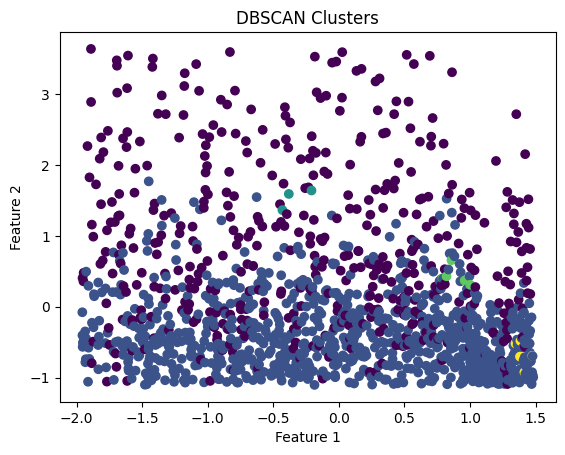

In [ ]:
# DBSCAN Clustering
# Applying DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(df_scaled)

# Add labels
df['DBSCAN_Cluster'] = db_labels

# Checking Clusters
print("Unique clusters:", set(db_labels))

# Evaluate DBSCAN
# Only if more than 1 cluster exists
if len(set(db_labels)) > 1:
    score_db = silhouette_score(df_scaled, db_labels)
    print("Silhouette Score (DBSCAN):", score_db)

# Visualize DBSCAN
plt.scatter(df_scaled.iloc[:,0], df_scaled.iloc[:,1], c=db_labels)
plt.title("DBSCAN Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
# Experiment with Parameters

# K-Means (Different K values)
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    print(f"K={k}, Silhouette Score:", silhouette_score(df_scaled, labels))

# DBSCAN (Different eps & min_samples)
for eps in [0.3, 0.5, 0.7]:
    for min_s in [3, 5, 10]:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(df_scaled)

        if len(set(labels)) > 1:
            score = silhouette_score(df_scaled, labels)
            print(f"eps={eps}, min_samples={min_s}, Score={score}")


K=2, Silhouette Score: 0.4353707260331255
K=3, Silhouette Score: 0.35660259963523355
K=4, Silhouette Score: 0.34849921314505655
K=5, Silhouette Score: 0.27684197436525937
K=6, Silhouette Score: 0.28121711464797544
eps=0.3, min_samples=3, Score=-0.4442464357855748
eps=0.3, min_samples=5, Score=-0.33294393720392157
eps=0.3, min_samples=10, Score=-0.2543880210003933
eps=0.5, min_samples=3, Score=-0.29633457547275277
eps=0.5, min_samples=5, Score=-0.1653377337849092
eps=0.5, min_samples=10, Score=0.030465665199014
eps=0.7, min_samples=3, Score=-0.0960405507747883
eps=0.7, min_samples=5, Score=0.21279471042152914
eps=0.7, min_samples=10, Score=0.3562748472379422


**Cluster Analysis and Interpretation:**

•	Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.


In [ ]:
# Analyze K-Means Clusters

# Mean values of each cluster
kmeans_analysis = df.groupby('KMeans_Cluster').mean()
kmeans_analysis

# Clusters size
df['KMeans_Cluster'].value_counts()

,count
KMeans_Cluster,
3,535
0,471
1,251
2,170


In [ ]:
# Analyze DBSCAN Clusters
# Mean values
dbscan_analysis = df.groupby('DBSCAN_Cluster').mean()
dbscan_analysis

# Cluster Distribution
df['DBSCAN_Cluster'].value_counts()

,count
DBSCAN_Cluster,
0,958
-1,456
2,5
3,5
1,3


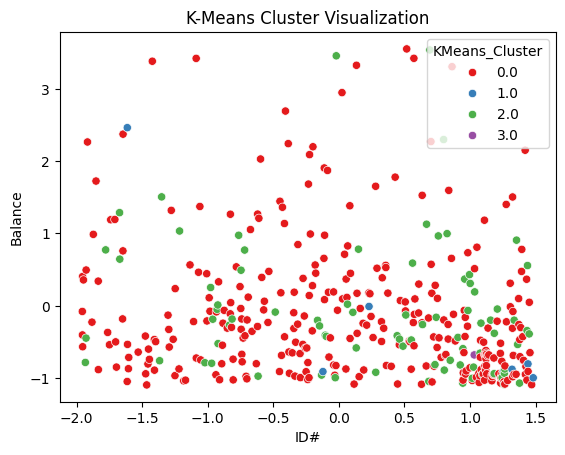

In [ ]:
# Visualization Insight
sns.scatterplot(
    x=df_scaled.iloc[:,0],
    y=df_scaled.iloc[:,1],
    hue=df['KMeans_Cluster'],
    palette='Set1'
)
plt.title("K-Means Cluster Visualization")
plt.show()

**Visualization:**

Visualize the clustering results using scatter plots or other suitable visualization techniques.

Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.


In [ ]:
# Apply PCA (for 2D Visualization)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

# Convert to DataFrame
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

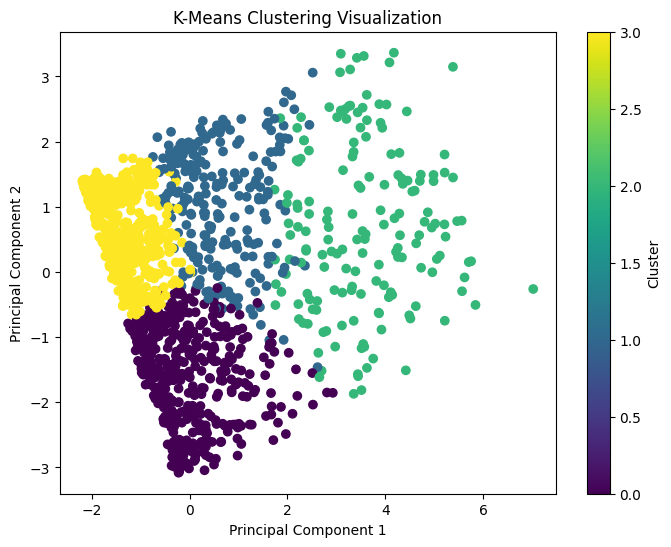

In [ ]:
# Visualize K-Means Clusters
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'],
            c=df['KMeans_Cluster'], cmap='viridis')

plt.title("K-Means Clustering Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Cluster')
plt.show()

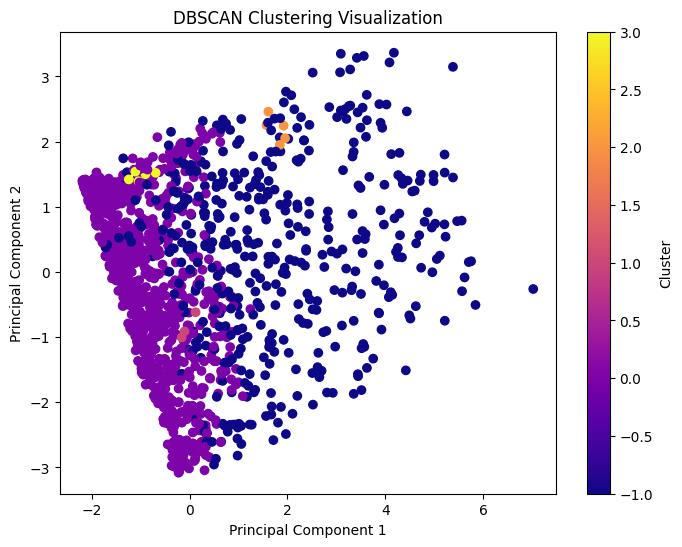

In [ ]:
# Visualize DBSCAN Clusters
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'],
            c=df['DBSCAN_Cluster'], cmap='plasma')

plt.title("DBSCAN Clustering Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Cluster')
plt.show()

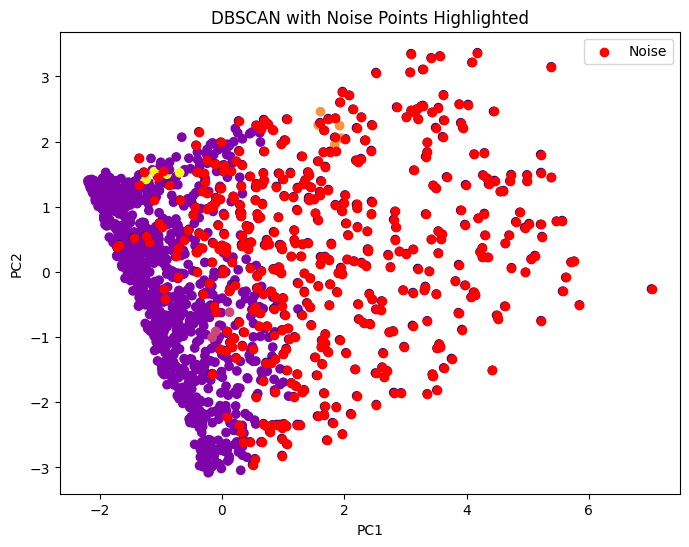

In [ ]:
# Highlight Noise Points
# Reset index to avoid mismatch
df = df.reset_index(drop=True)
pca_df = pca_df.reset_index(drop=True)

plt.figure(figsize=(8,6))

# Plot clusters
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=df['DBSCAN_Cluster'],
    cmap='plasma'
)

# Highlight noise (-1)
noise = df['DBSCAN_Cluster'] == -1

plt.scatter(
    pca_df.loc[noise, 'PC1'],
    pca_df.loc[noise, 'PC2'],
    color='red',
    label='Noise'
)

plt.legend()
plt.title("DBSCAN with Noise Points Highlighted")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

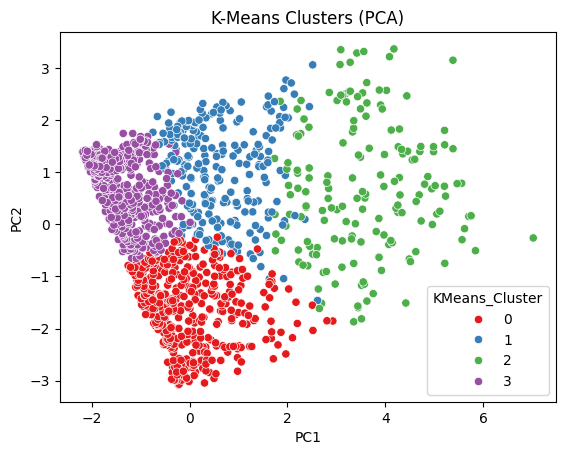

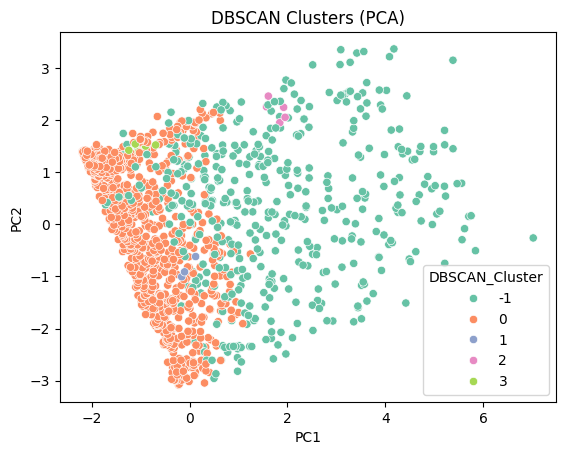

In [ ]:
# Better Visualization (Seaborn)
# K-Means
sns.scatterplot(
    x='PC1', y='PC2',
    hue=df['KMeans_Cluster'],
    data=pca_df,
    palette='Set1'
)
plt.title("K-Means Clusters (PCA)")
plt.show()

# DBSCAN
sns.scatterplot(
    x='PC1', y='PC2',
    hue=df['DBSCAN_Cluster'],
    data=pca_df,
    palette='Set2'
)
plt.title("DBSCAN Clusters (PCA)")
plt.show()

**Visualization Insight :**

1. PCA is used to reduce high-dimensional data into 2D

2. Scatter plots clearly show separation between clusters

**K-Means Visualization :**

1. Clusters are clearly separated

2. Each color represents a different customer segment

**DBSCAN Visualization :**

1. Dense clusters are visible

2. Noise points (outliers) are highlighted separately

**Evaluation and Performance Metrics:**

Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.


In [ ]:
# Import Metric
from sklearn.metrics import silhouette_score

# Evaluate K- Means
kmeans_score = silhouette_score(df_scaled, df['KMeans_Cluster'])
print("Silhouette Score for K-Means:", kmeans_score)

# Evaluate DBSCAN
# Remove noise points
dbscan_filtered = df[df['DBSCAN_Cluster'] != -1]
df_scaled_filtered = df_scaled[df['DBSCAN_Cluster'] != -1]

# Check if valid clusters exist
if len(set(dbscan_filtered['DBSCAN_Cluster'])) > 1:
    dbscan_score = silhouette_score(
        df_scaled_filtered,
        dbscan_filtered['DBSCAN_Cluster']
    )
    print("Silhouette Score for DBSCAN:", dbscan_score)
else:
    print("DBSCAN did not form enough clusters for evaluation")

# Comparing Results
print("K-Means Score:", kmeans_score)

if 'dbscan_score' in locals():
    print("DBSCAN Score:", dbscan_score)

Silhouette Score for K-Means: 0.34849921314505655
Silhouette Score for DBSCAN: -0.09316034256707398
K-Means Score: 0.34849921314505655
DBSCAN Score: -0.09316034256707398


**Conclusion :**

Silhouette score was used to evaluate clustering performance
, K-Means provided (higher/lower) score compared to DBSCAN.

DBSCAN effectively identified noise (outliers)
, K-Means produced well-separated clusters